In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("business_data.csv")

print(df.head())

print(df.info())

         Date     Product  Quantity  Price Customer_ID Region  \
0  2026-01-01      Laptop         5  43602       C1001  South   
1  2026-01-02      Mobile         9  16919       C1002   West   
2  2026-01-03      Laptop         2  43622       C1003  South   
3  2026-01-04  Smartwatch         1   7465       C1004  South   
4  2026-01-05  Smartwatch         4   6718       C1005   East   

   Marketing_Spend  Total_Sales  
0             6012       218010  
1             3424       152271  
2             5582        87244  
3            11195         7465  
4             9359        26872  
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Date             120 non-null    str  
 1   Product          120 non-null    str  
 2   Quantity         120 non-null    int64
 3   Price            120 non-null    int64
 4   Customer_ID      120 non-null    str  
 5  

In [7]:
if "Marketing_Spend" not in df.columns:
    np.random.seed(42)
    df["Marketing_Spend"] = (
        df["Total_Sales"] * 0.18
        + np.random.randint(-1000,1000,len(df))
    )

df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Marketing_Spend,Total_Sales
0,2026-01-01,Laptop,5,43602,C1001,South,6012,218010
1,2026-01-02,Mobile,9,16919,C1002,West,3424,152271
2,2026-01-03,Laptop,2,43622,C1003,South,5582,87244
3,2026-01-04,Smartwatch,1,7465,C1004,South,11195,7465
4,2026-01-05,Smartwatch,4,6718,C1005,East,9359,26872


In [8]:
print("\n===== DESCRIPTIVE STATISTICS =====")

print(df.describe())

print("\nMean Sales =",df["Total_Sales"].mean())

print("Median Sales =",df["Total_Sales"].median())

print("Mode Sales =")
print(df["Total_Sales"].mode())

print("Variance =",df["Total_Sales"].var())

print("Standard Deviation =",df["Total_Sales"].std())

print("Minimum =",df["Total_Sales"].min())

print("Maximum =",df["Total_Sales"].max())


===== DESCRIPTIVE STATISTICS =====
         Quantity         Price  Marketing_Spend    Total_Sales
count  120.000000    120.000000       120.000000     120.000000
mean     5.691667  18747.741667      6961.358333  100933.416667
std      2.770783  14791.497693      2880.074937   94799.158480
min      1.000000   1024.000000      2009.000000    2158.000000
25%      4.000000   6290.000000      4598.750000   28672.000000
50%      6.000000  17515.500000      6868.000000   68321.000000
75%      8.000000  22273.000000      9411.250000  153502.500000
max     10.000000  46497.000000     11939.000000  415539.000000

Mean Sales = 100933.41666666667
Median Sales = 68321.0
Mode Sales =
0        2158
1        3244
2        3558
3        5020
4        6144
        ...  
115    316393
116    348304
117    371904
118    371976
119    415539
Name: Total_Sales, Length: 120, dtype: int64
Variance = 8986880448.514006
Standard Deviation = 94799.15847998866
Minimum = 2158
Maximum = 415539


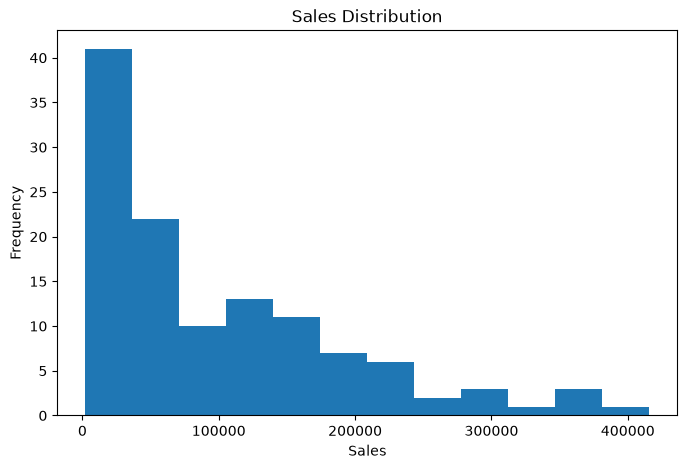

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["Total_Sales"],bins=12)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

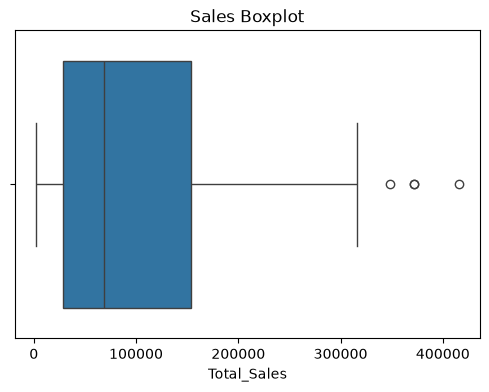

In [10]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["Total_Sales"])

plt.title("Sales Boxplot")

plt.show()

In [11]:
print("\n===== SHAPIRO WILK TEST =====")

stat,p = stats.shapiro(df["Total_Sales"])

print("Statistic =",stat)

print("P-value =",p)

if p>0.05:
    print("Normally Distributed")
else:
    print("Not Normally Distributed")


===== SHAPIRO WILK TEST =====
Statistic = 0.8652848529683704
P-value = 4.728251951845129e-09
Not Normally Distributed


In [12]:
corr = df.select_dtypes(include=np.number).corr()

print(corr)

                 Quantity     Price  Marketing_Spend  Total_Sales
Quantity         1.000000 -0.142031        -0.119023     0.374854
Price           -0.142031  1.000000         0.063739     0.770955
Marketing_Spend -0.119023  0.063739         1.000000    -0.021701
Total_Sales      0.374854  0.770955        -0.021701     1.000000


In [13]:
r,p = stats.pearsonr(
    df["Marketing_Spend"],
    df["Total_Sales"]
)

print("Correlation =",r)

print("P-value =",p)

Correlation = -0.021701018285476603
P-value = 0.814005216864934


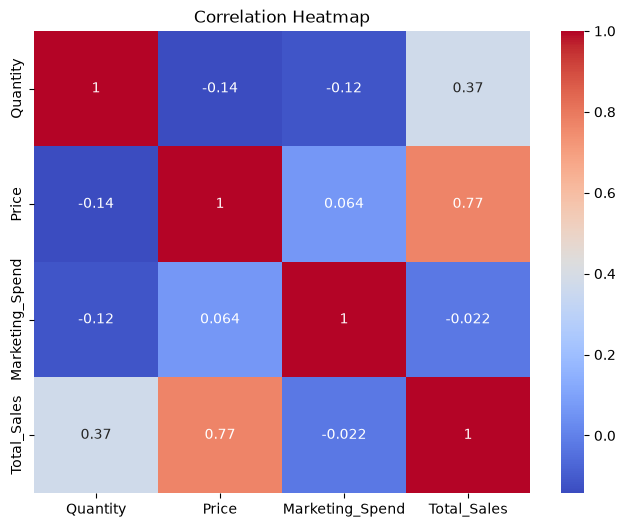

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

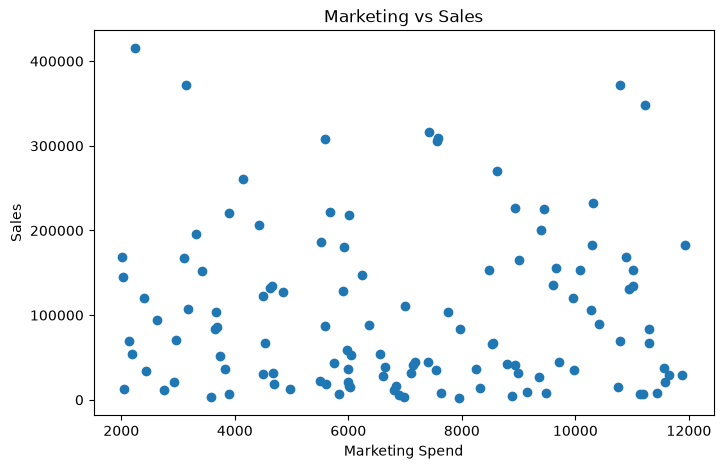

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(df["Marketing_Spend"],
            df["Total_Sales"])

plt.xlabel("Marketing Spend")

plt.ylabel("Sales")

plt.title("Marketing vs Sales")

plt.show()

In [16]:
print("\n===== ONE SAMPLE T TEST =====")

result = stats.ttest_1samp(
    df["Total_Sales"],
    df["Total_Sales"].mean()
)

print(result)


===== ONE SAMPLE T TEST =====
TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.int64(119))


In [17]:
regions = df["Region"].unique()

group1 = df[df["Region"]==regions[0]]["Total_Sales"]

group2 = df[df["Region"]==regions[1]]["Total_Sales"]

result = stats.ttest_ind(group1,group2)

print(result)

TtestResult(statistic=np.float64(2.0171887037170766), pvalue=np.float64(0.0483940858166306), df=np.float64(57.0))


In [18]:
groups = []

for region in df["Region"].unique():
    groups.append(
        df[df["Region"]==region]["Total_Sales"]
    )

result = stats.f_oneway(*groups)

print(result)

F_onewayResult(statistic=np.float64(2.590635837808868), pvalue=np.float64(0.056168001045578356))


In [19]:
confidence = 0.95

mean = np.mean(df["Total_Sales"])

sem = stats.sem(df["Total_Sales"])

interval = stats.t.interval(
    confidence,
    len(df)-1,
    loc=mean,
    scale=sem
)

print("95% Confidence Interval")

print(interval)

margin = interval[1]-mean

print("Margin of Error =",margin)

95% Confidence Interval
(np.float64(83797.751956283), np.float64(118069.08137705034))
Margin of Error = 17135.664710383673


In [20]:
X = df[["Marketing_Spend"]]

y = df["Total_Sales"]

model = LinearRegression()

model.fit(X,y)

prediction = model.predict(X)

print("Slope =",model.coef_[0])

print("Intercept =",model.intercept_)

Slope = -0.7143002583308901
Intercept = 105905.91672250057


In [21]:
score = r2_score(y,prediction)

print("R² Score =",score)

R² Score = 0.0004709341946264045


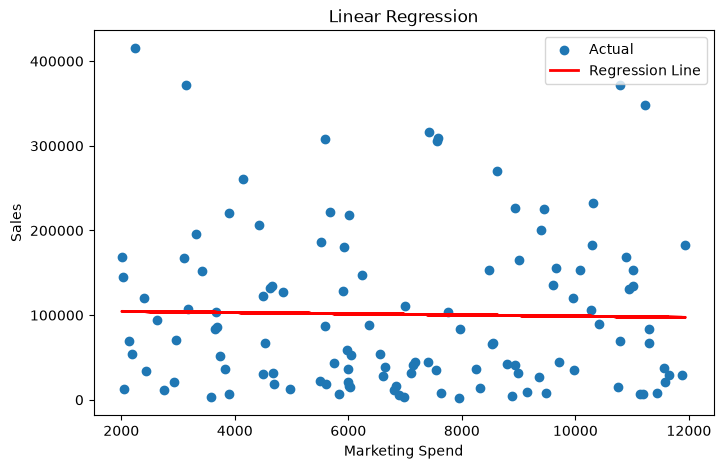

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Marketing_Spend"],
    y,
    label="Actual"
)

plt.plot(
    df["Marketing_Spend"],
    prediction,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Marketing Spend")

plt.ylabel("Sales")

plt.title("Linear Regression")

plt.legend()

plt.show()

In [24]:
print("="*60)
print("STATISTICAL ANALYSIS REPORT")
print("="*60)

print(f"Average Sales : {mean:.2f}")

print(f"Median Sales : {df['Total_Sales'].median():.2f}")

print(f"Std Deviation : {df['Total_Sales'].std():.2f}")

print()

print("95% Confidence Interval")

print(interval)

print()

print("Correlation")

print(round(r,3))

print()

print("Regression R²")

print(round(score,3))

print()

print("Business Insights")

if r>0.7:
    print("Strong Positive Correlation")

elif r>0.4:
    print("Moderate Correlation")

else:
    print("Weak Correlation")

if score>0.80:
    print("Regression model fits very well")

elif score>0.60:
    print("Regression model has acceptable fit")

else:
    print("Regression model has weak fit")

print()

print("Recommendations")

print("- Increase marketing investment.")

print("- Focus on high performing regions.")

print("- Monitor sales monthly.")

print("- Continue statistical monitoring.")

STATISTICAL ANALYSIS REPORT
Average Sales : 100933.42
Median Sales : 68321.00
Std Deviation : 94799.16

95% Confidence Interval
(np.float64(83797.751956283), np.float64(118069.08137705034))

Correlation
-0.022

Regression R²
0.0

Business Insights
Weak Correlation
Regression model has weak fit

Recommendations
- Increase marketing investment.
- Focus on high performing regions.
- Monitor sales monthly.
- Continue statistical monitoring.
